# Section 3 - Export Side of AI-Related Trade
Generates: figures/ai-exports-index, ai-exports-by-country, ai-exports-by-country-category.
**Run after 06** - appends to tables/ai-trade-results.tex.


In [13]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [14]:
figfile = 'paper/figures/'
texfile = 'paper/tables/ai-trade-results.tex'


In [15]:
matlist = pd.read_csv('data-input/hs10_classification_imports_exports.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

print(matlist["relevance"].value_counts().reindex(["Low", "Medium", "High"]).to_string())

relevance
Low       20023
Medium     3265
High        829


In [16]:
df = pd.read_parquet('data-input/TOTALexports-combined.parquet')

df.rename(columns={'E_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["exports"] = df["ALL_VAL_MO"].astype(float)

# df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"E_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# # Remove volatile/special HS2 categories
# # These categories have prices that are either:
# # - Extremely volatile (oil, precious metals)
# # - Lumpy/irregular (aircraft)
# # - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [17]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [18]:
grp = df.groupby(['relevance', 'time'], observed=True)

grp_sum = grp[['exports']].sum().reset_index()

grp = df.groupby(['time'], observed=True)

grp_total = grp[['exports']].sum().reset_index()

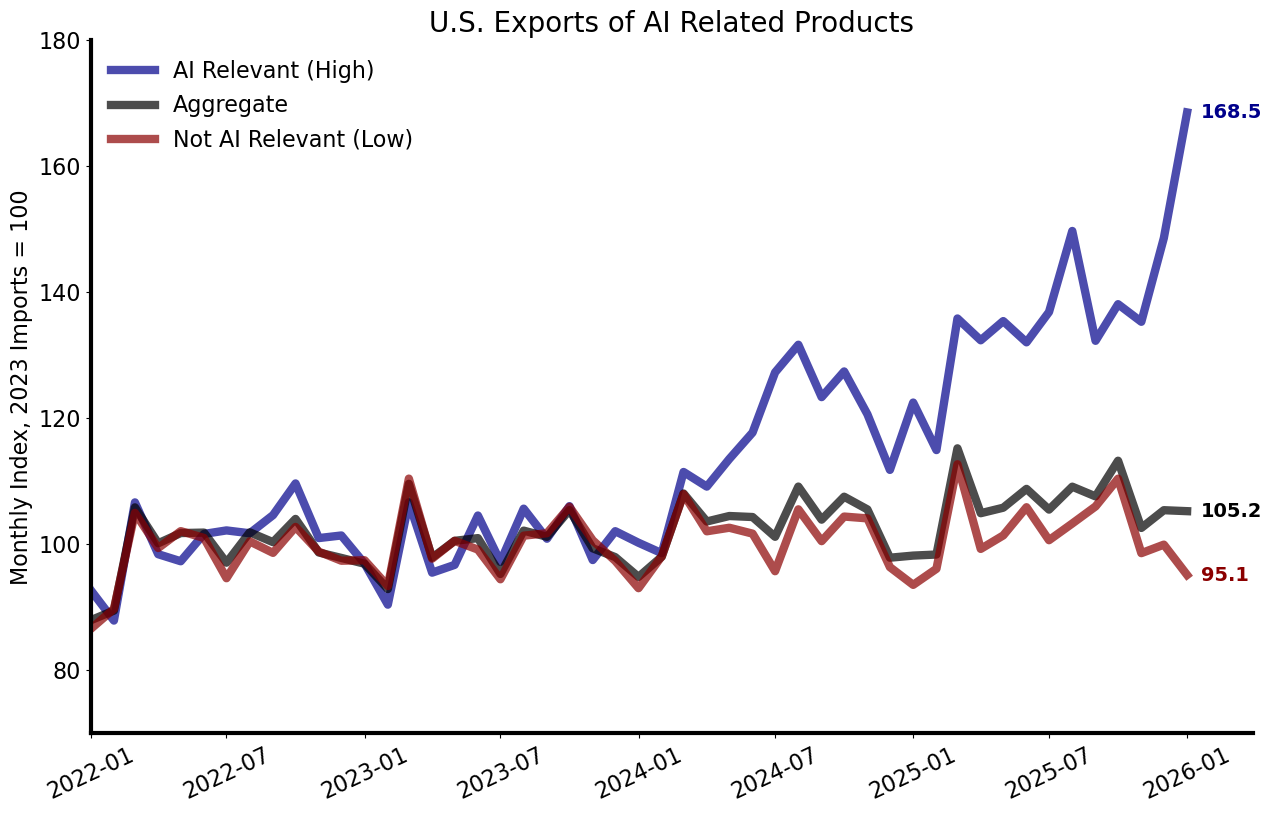

In [20]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["exports"] / foo["exports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant (High)')

foo2 = grp_total.copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["exports"] / foo2["exports"].loc["2023"].sum()) ,
         color = "black", alpha = 0.7, linewidth = 6, label='Aggregate')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["exports"] / foo3["exports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant (Low)')

# Add annotations for last observations
last_date_ai = foo.index[-1]
last_value_ai = 100*(12*foo["exports"].iloc[-1] / foo["exports"].loc["2023"].sum())
ax.annotate(f'{last_value_ai:.1f}', 
            xy=(last_date_ai, last_value_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkblue',
            va='center')

last_date_agg = foo2.index[-1]
last_value_agg = 100*(12*foo2["exports"].iloc[-1] / foo2["exports"].loc["2023"].sum())
ax.annotate(f'{last_value_agg:.1f}', 
            xy=(last_date_agg, last_value_agg),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='black',
            va='center')

last_date_not_ai = foo3.index[-1]
last_value_not_ai = 100*(12*foo3["exports"].iloc[-1] / foo3["exports"].loc["2023"].sum())
ax.annotate(f'{last_value_not_ai:.1f}', 
            xy=(last_date_not_ai, last_value_not_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkred',
            va='center')

ax.set_title("U.S. Exports of AI Related Products", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2026,3,30)])

ax.set_ylim(70,180)

ax.tick_params(axis='x', labelsize=16, rotation=25)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Monthly Index, 2023 Imports = 100", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

plt.savefig(figfile + 'ai-exports-index.png', bbox_inches='tight')
plt.savefig(figfile + 'ai-exports-index.pdf', bbox_inches='tight')
plt.show()

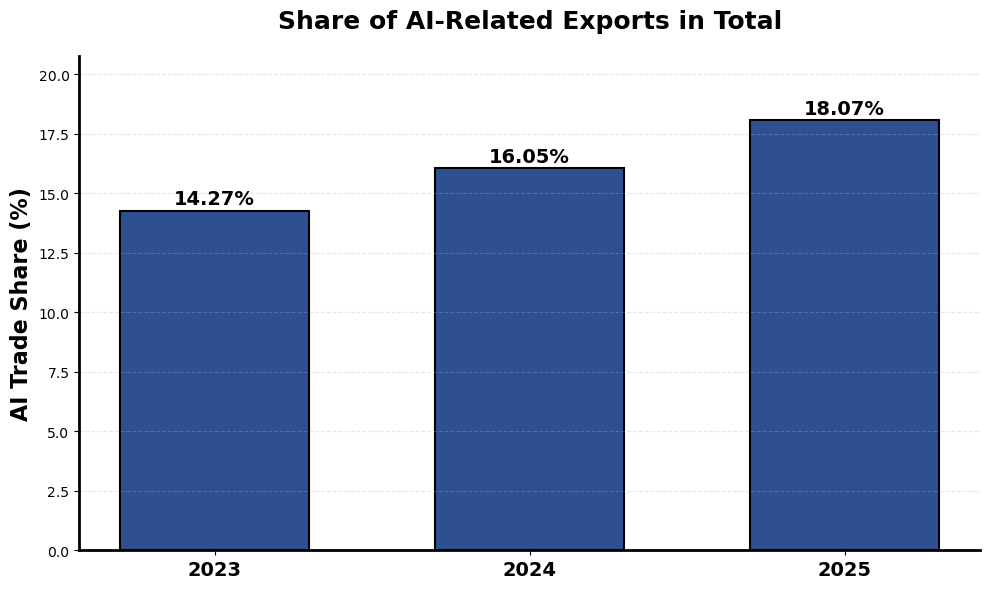


AI Trade Share:
  2023: 14.27%
  2024: 16.05%
  2025: 18.07%

Growth: 3.80 percentage points


In [21]:
# Calculate AI trade share for each year (2023-2025)
years = [2023, 2024, 2025]
ai_shares = []

foo = grp_sum[grp_sum['relevance']=='High'].copy().set_index("time")
df_indexed = df.set_index("time")  # local view — does not mutate df

for year in years:
    year_str = str(year)
    total_trade = df_indexed.exports.loc[year_str].sum()
    ai_trade = foo.exports.loc[year_str].sum()
    ai_share = (ai_trade / total_trade) * 100
    ai_shares.append(ai_share)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(years, ai_shares, color='#2E5090', edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for i, (year, share) in enumerate(zip(years, ai_shares)):
    ax.text(year, share + 0.1, f'{share:.2f}%', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Formatting
# ax.set_xlabel('Year', fontsize=16, fontweight='bold')
ax.set_ylabel('AI Trade Share (%)', fontsize=16, fontweight='bold')
ax.set_title('Share of AI-Related Exports in Total', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(years)
ax.set_ylim(0, max(ai_shares) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.savefig(figfile + 'ai-exports-share.png', bbox_inches='tight')
plt.savefig(figfile + 'ai-exports-share.pdf', bbox_inches='tight')
plt.show()

print(f"\nAI Trade Share:")
for year, share in zip(years, ai_shares):
    print(f"  {year}: {share:.2f}%")
print(f"\nGrowth: {ai_shares[-1] - ai_shares[0]:.2f} percentage points")


In [22]:
# Calculate values for the table
df_reset = df.reset_index()

# Count unique HS10 codes by relevance
high_hs_count = df_reset[df_reset['relevance'] == 'High']['HS10'].nunique()
low_hs_count = df_reset[df_reset['relevance'] == 'Low']['HS10'].nunique()
total_hs_count = df_reset[df_reset['time'].dt.year == 2024]['HS10'].nunique()

# 2023 values
high_2023 = df_reset[(df_reset['time'].dt.year == 2023) & (df_reset['relevance'] == 'High')]['exports'].sum()
low_2023 = df_reset[(df_reset['time'].dt.year == 2023) & (df_reset['relevance'] == 'Low')]['exports'].sum()
total_2023 = df_reset[df_reset['time'].dt.year == 2023]['exports'].sum()

# 2025 values
high_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'High')]['exports'].sum()
low_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'Low')]['exports'].sum()
total_2025 = df_reset[df_reset['time'].dt.year == 2025]['exports'].sum()

# Calculate percent increases
high_pct = ((high_2025 - high_2023) / high_2023) * 100
low_pct = ((low_2025 - low_2023) / low_2023) * 100
total_pct = ((total_2025 - total_2023) / total_2023) * 100

In [23]:
# Calculate values for the table
df_reset = df.reset_index()

# Get high relevance only
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

# Get all categories (excluding Not_DC_Related, Maintenance_Operations, and NaN)
all_cats = [cat for cat in df_high_only['primary_category'].unique() 
            if pd.notna(cat) and cat != 'Not_DC_Related' and cat != 'Maintenance_Operations']

category_data = {}
for cat in all_cats:
    cat_data = df_high_only[df_high_only['primary_category'] == cat]
    
    # Count unique HS10 codes
    hs_count = cat_data['HS10'].nunique()
    
    # 2023 values
    cat_2023 = cat_data[cat_data['time'].dt.year == 2023]['exports'].sum()
    
    # 2025 values
    cat_2025 = cat_data[cat_data['time'].dt.year == 2025]['exports'].sum()
    
    # Calculate percent increase
    cat_pct = ((cat_2025 - cat_2023) / cat_2023) * 100 if cat_2023 > 0 else 0
    
    category_data[cat] = {
        'hs_count': hs_count,
        '2023': cat_2023,
        '2025': cat_2025,
        'pct': cat_pct
    }

# Calculate totals for High AI Relevance
# Sort categories by 2023 dollar value (descending)
all_cats = sorted(category_data.keys(), key=lambda x: category_data[x]['2023'], reverse=True)

# Calculate totals for High AI Relevance
total_high_hs_count = df_high_only['HS10'].nunique()
total_high_2023 = df_high_only[df_high_only['time'].dt.year == 2023]['exports'].sum()
total_high_2025 = df_high_only[df_high_only['time'].dt.year == 2025]['exports'].sum()
total_high_pct = ((total_high_2025 - total_high_2023) / total_high_2023) * 100

In [24]:
# Generate combined hierarchical LaTeX table for trade values
# Shows High AI Relevance with subcategories, then Low AI Relevance, then Total

import os
os.makedirs('paper/tables', exist_ok=True)

# Use the data already calculated in previous cells
# high_hs_count, high_2023, high_2025, high_pct (from relevance table)
# low_hs_count, low_2023, low_2025, low_pct (from relevance table)
# total_hs_count, total_2023, total_2025, total_pct (from relevance table)
# category_data, all_cats (from category table)

# Generate combined hierarchical table
table_file = "paper/tables/trade_hierarchical_exports.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{U.S. Export Values by AI Relevance and Category (2023 vs 2025)}\n")
    f.write("\\label{tab:trade_hierarchical_exports}\n")
    f.write("\\setlength{\\tabcolsep}{4.5mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("\\begin{tabular}{lrrrr}\n")
    f.write("\\toprule\n")
    f.write("Category & \\# HS10 Codes & 2023 (\\$B) & 2025 (\\$B) & Change (\\%) \\\\\n")
    f.write("\\midrule\n")
    
    # High AI Relevance (main row)
    f.write(f"High AI Relevance & {high_hs_count} & {high_2023/1e9:.1f} & {high_2025/1e9:.1f} & {high_pct:+.1f} \\\\\n")
    
    # Subcategories (indented)
    for cat in all_cats:
        cat_name = cat.replace('_', ' ')
        data = category_data[cat]
        # Use \quad\quad for indentation
        f.write(f"\\quad\\quad {cat_name} & {data['hs_count']} & {data['2023']/1e9:.1f} & {data['2025']/1e9:.1f} & {data['pct']:+.1f} \\\\\n")
    
    # Low AI Relevance
    f.write(f"Low AI Relevance & {low_hs_count} & {low_2023/1e9:.1f} & {low_2025/1e9:.1f} & {low_pct:+.1f} \\\\\n")
    
    f.write("\\midrule\n")
    
    # Total Trade
    f.write(f"Total Trade & {total_hs_count} & {total_2023/1e9:.1f} & {total_2025/1e9:.1f} & {total_pct:+.1f} \\\\\n")
    
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}\n")
print("LaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nSummary:")
print(f"High AI Relevance: {high_hs_count} HS10 codes | ${high_2023/1e9:.1f}B (2023) → ${high_2025/1e9:.1f}B (2025) [{high_pct:+.1f}%]")
for cat in all_cats:
    data = category_data[cat]
    cat_name = cat.replace('_', ' ')
    print(f"  └─ {cat_name}: {data['hs_count']} HS10 codes | ${data['2023']/1e9:.1f}B (2023) → ${data['2025']/1e9:.1f}B (2025) [{data['pct']:+.1f}%]")
print(f"Low AI Relevance: {low_hs_count} HS10 codes | ${low_2023/1e9:.1f}B (2023) → ${low_2025/1e9:.1f}B (2025) [{low_pct:+.1f}%]")
print(f"Total Trade: {total_hs_count} HS10 codes | ${total_2023/1e9:.1f}B (2023) → ${total_2025/1e9:.1f}B (2025) [{total_pct:+.1f}%]")




Generated: paper/tables/trade_hierarchical_exports.tex

LaTeX Table:
\begin{table}[htbp]
\centering
\caption{U.S. Export Values by AI Relevance and Category (2023 vs 2025)}
\label{tab:trade_hierarchical_exports}
\setlength{\tabcolsep}{4.5mm}
\renewcommand{\arraystretch}{1.60}
\begin{tabular}{lrrrr}
\toprule
Category & \# HS10 Codes & 2023 (\$B) & 2025 (\$B) & Change (\%) \\
\midrule
High AI Relevance & 534 & 221.5 & 297.9 & +34.5 \\
\quad\quad Compute Hardware & 112 & 99.1 & 160.6 & +62.1 \\
\quad\quad Electrical Power & 219 & 64.5 & 70.1 & +8.8 \\
\quad\quad Networking Telecom & 23 & 29.1 & 37.7 & +29.7 \\
\quad\quad Cooling HVAC & 128 & 24.1 & 25.0 & +3.5 \\
\quad\quad Building Structure & 28 & 3.0 & 2.8 & -6.8 \\
\quad\quad Specialty Materials & 16 & 0.7 & 0.6 & -9.6 \\
\quad\quad Fire Safety Security & 7 & 0.5 & 0.6 & +13.4 \\
Low AI Relevance & 8278 & 1034.8 & 1058.6 & +2.3 \\
\midrule
Total Trade & 9269 & 1551.9 & 1648.4 & +6.2 \\
\bottomrule
\end{tabular}
\end{table}


Summary:


In [25]:
dfcountry = pd.read_parquet('data-input/ALL-country-exports.parquet')

dfcountry.rename(columns={'E_COMMODITY': 'HS10'}, inplace=True)

dfcountry["HS2"] = dfcountry["HS10"].str[0:2]
dfcountry["HS4"] = dfcountry["HS10"].str[0:4]

dfcountry["HS10"] = dfcountry["HS10"].astype('int64')

dfcountry.time = pd.to_datetime(dfcountry.time, format="%Y-%m")

dfcountry["exports"] = dfcountry["ALL_VAL_MO"].astype(float)


dfcountry.rename({"E_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
dfcountry = dfcountry[~dfcountry["HS2"].isin(excluded_hs2)]

excluded_cntry = ["TOTAL FOR ALL COUNTRIES", "USMCA (NAFTA)", "EUROPEAN UNION"]
dfcountry = dfcountry[~dfcountry["CTY_NAME"].isin(excluded_cntry)]

# Merge Relevance category from matlist onto df
dfcountry = dfcountry.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

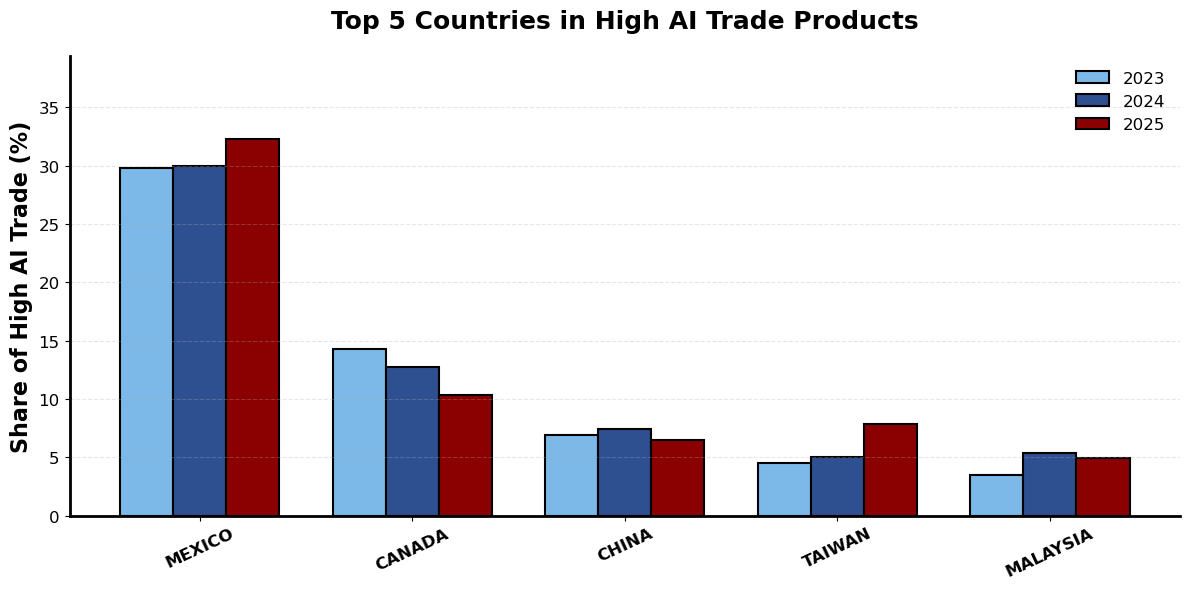

In [26]:
# Top 5 countries in High AI trade products, split by year (2023, 2024, 2025)

period_years = [2023, 2024, 2025]

country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Select top 5 countries based on combined 2024-2025 imports
country_exports_total = (
    country_high[country_high['time'].dt.year.isin([2024, 2025])]
    .groupby('CTY_NAME', observed=True)['exports']
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_exports_total.head(5).index.tolist()

# Compute yearly shares: country high-AI exports / total high-AI exports in that year
yearly_country_exports = (
    country_high[country_high['CTY_NAME'].isin(top5_countries)]
    .groupby(['CTY_NAME', country_high['time'].dt.year], observed=True)['exports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=period_years, fill_value=0)
)

yearly_high_totals = (
    country_high.groupby(country_high['time'].dt.year, observed=True)['exports']
    .sum()
)

plot_df = pd.DataFrame({
    '2023': (yearly_country_exports[2023] / yearly_high_totals.loc[2023]) * 100,
    '2024': (yearly_country_exports[2024] / yearly_high_totals.loc[2024]) * 100,
    '2025': (yearly_country_exports[2025] / yearly_high_totals.loc[2025]) * 100
}).loc[top5_countries]

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(plot_df.index))
width = 0.25

bars_2023 = ax.bar(
    x - width,
    plot_df['2023'].values,
    width,
    label='2023',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

bars_2024 = ax.bar(
    x,
    plot_df['2024'].values,
    width,
    label='2024',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_2025 = ax.bar(
    x + width,
    plot_df['2025'].values,
    width,
    label='2025',
    color='#8B0000',
    edgecolor='black',
    linewidth=1.5
)

# Formatting (consistent with existing style)
ax.set_ylabel('Share of High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 5 Countries in High AI Trade Products', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(plot_df['2023'].max(), plot_df['2024'].max(), plot_df['2025'].max()) * 1.22)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.legend(fontsize=12, frameon=False, loc='upper right')



plt.tight_layout()
plt.show()


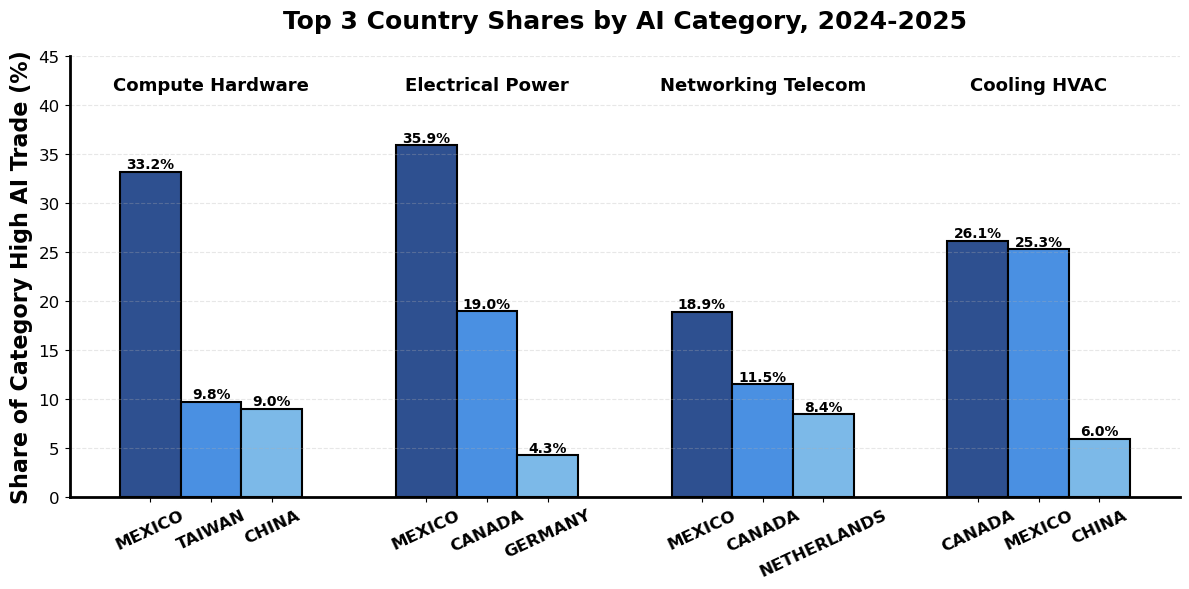


Top 3 country shares within each category (2024-2025):
  Compute Hardware:
    1) MEXICO: 33.2%
    2) TAIWAN: 9.8%
    3) CHINA: 9.0%
  Electrical Power:
    1) MEXICO: 35.9%
    2) CANADA: 19.0%
    3) GERMANY: 4.3%
  Networking Telecom:
    1) MEXICO: 18.9%
    2) CANADA: 11.5%
    3) NETHERLANDS: 8.4%
  Cooling HVAC:
    1) CANADA: 26.1%
    2) MEXICO: 25.3%
    3) CHINA: 6.0%


In [27]:
# Top 3 country shares within each top AI category (2024-2025)

period_years = [2024, 2025]
category_list = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

cat_country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['primary_category'].isin(category_list)) &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Compute top-3 country shares within each category
share_by_rank = {'Top 1': [], 'Top 2': [], 'Top 3': []}
country_names_by_cat = {}

for category in category_list:
    category_data = cat_country_high[cat_country_high['primary_category'] == category]
    country_exports = category_data.groupby('CTY_NAME', observed=True)['exports'].sum().sort_values(ascending=False)

    category_total = country_exports.sum()
    top3 = country_exports.head(3)

    # Pad if fewer than 3 countries
    top3_shares = (top3 / category_total * 100).tolist()
    top3_names = top3.index.tolist()

    while len(top3_shares) < 3:
        top3_shares.append(0.0)
        top3_names.append('N/A')

    share_by_rank['Top 1'].append(top3_shares[0])
    share_by_rank['Top 2'].append(top3_shares[1])
    share_by_rank['Top 3'].append(top3_shares[2])

    country_names_by_cat[category] = top3_names

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(category_list))
width = 0.22

bars_top1 = ax.bar(
    x - width,
    share_by_rank['Top 1'],
    width,
    label='Top 1 Country',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_top2 = ax.bar(
    x,
    share_by_rank['Top 2'],
    width,
    label='Top 2 Country',
    color='#4A90E2',
    edgecolor='black',
    linewidth=1.5
)

bars_top3 = ax.bar(
    x + width,
    share_by_rank['Top 3'],
    width,
    label='Top 3 Country',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

# Labels on bars (percent values)
for bars in [bars_top1, bars_top2, bars_top3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# X-axis labels: country names under each bar
bar_positions = []
bar_labels = []
for idx, category in enumerate(category_list):
    c1, c2, c3 = country_names_by_cat[category]
    bar_positions.extend([x[idx] - width, x[idx], x[idx] + width])
    bar_labels.extend([c1, c2, c3])

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels)

# Category annotations centered on middle bar of each group (~42%)
max_share = max(max(share_by_rank['Top 1']), max(share_by_rank['Top 2']), max(share_by_rank['Top 3']))
category_label_y = 42
top_ylim = max(max_share * 1.22, category_label_y + 3)

for idx, category in enumerate(category_list):
    ax.text(
        x[idx],
        category_label_y,
        category.replace('_', ' '),
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold'
    )

# Formatting (consistent style)
ax.set_ylabel('Share of Category High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 3 Country Shares by AI Category, 2024-2025', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, top_ylim)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)



plt.tight_layout()
plt.savefig(figfile + 'ai-exports-by-country-category.png', bbox_inches='tight')
plt.savefig(figfile + 'ai-exports-by-country-category.pdf', bbox_inches='tight')
plt.show()

print('\nTop 3 country shares within each category (2024-2025):')
for category in category_list:
    c1, c2, c3 = country_names_by_cat[category]
    i = category_list.index(category)
    print(f"  {category.replace('_', ' ')}:")
    print(f"    1) {c1}: {share_by_rank['Top 1'][i]:.1f}%")
    print(f"    2) {c2}: {share_by_rank['Top 2'][i]:.1f}%")
    print(f"    3) {c3}: {share_by_rank['Top 3'][i]:.1f}%")